In [6]:
import pandas as pd

df = pd.read_json('../interact_with_model/out_fewshot/preds_all.jsonl', lines=True)
df.head()

,id,model_id,gold_label,pred_label,rationale,parse_ok,raw_text
0,1,google/gemma-2-9b-it,HIGH_UNCERTAINTY,HIGH_UNCERTAINTY,The answer to the Yme claim question is vague ...,True,"```json\n{\n ""label"": ""HIGH_UNCERTAINTY"",\n ""r..."
1,1,Qwen/Qwen2.5-7B-Instruct,HIGH_UNCERTAINTY,INTERMEDIATE_UNCERTAINTY,The conversation includes some conditional out...,True,"```json\n{\n ""label"": ""INTERMEDIATE_UNCERTAIN..."
2,1,meta-llama/Llama-3.1-8B-Instruct,HIGH_UNCERTAINTY,HIGH_UNCERTAINTY,The CEO mentions that the discussions with the...,True,"{\n ""label"": ""HIGH_UNCERTAINTY"",\n ""rational..."
3,2,google/gemma-2-9b-it,NO_UNCERTAINTY,INTERMEDIATE_UNCERTAINTY,The CEO mentions several future markets and st...,True,"```json\n{\n ""label"": ""INTERMEDIATE_UNCERTAINT..."
4,2,Qwen/Qwen2.5-7B-Instruct,NO_UNCERTAINTY,NO_UNCERTAINTY,The answer provides clear expectations for fut...,True,"```json\n{\n ""label"": ""NO_UNCERTAINTY"",\n ""r..."


In [13]:
gemma_labels = df[df['model_id']=='google/gemma-2-9b-it']['pred_label'].values
qwen_labels = df[df['model_id']=='Qwen/Qwen2.5-7B-Instruct']['pred_label'].values
llama_labels = df[df['model_id']=='meta-llama/Llama-3.1-8B-Instruct']['pred_label'].values

In [19]:
(gemma_labels == qwen_labels).sum() / len(gemma_labels)

np.float64(0.518)

In [20]:
(gemma_labels == llama_labels).sum() / len(gemma_labels)


np.float64(0.27)

In [21]:
(llama_labels == qwen_labels).sum() / len(llama_labels)

np.float64(0.624)

(array([0, 1, 2]),
 [Text(0, 0, 'NO_UNCERTAINTY'),
  Text(1, 0, 'INTERMEDIATE_UNCERTAINTY'),
  Text(2, 0, 'HIGH_UNCERTAINTY')])

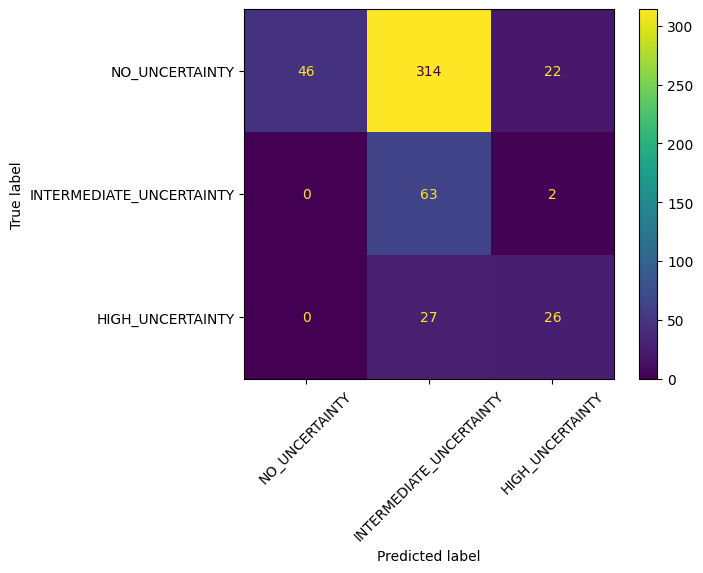

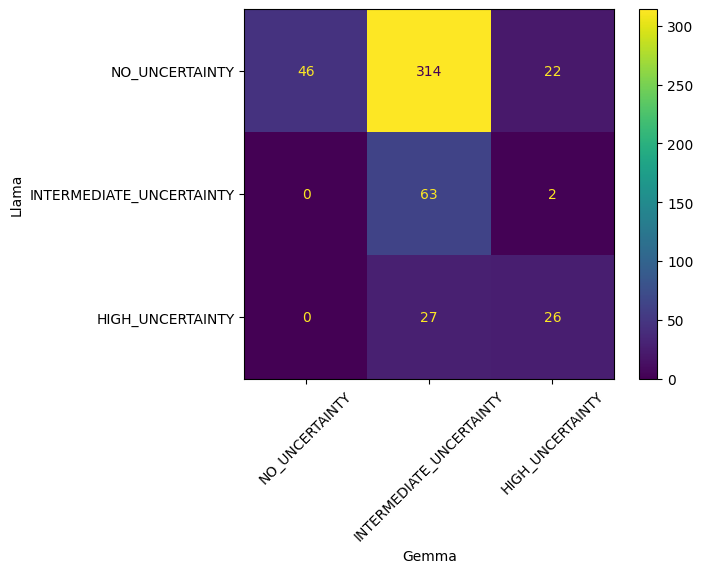

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    llama_labels, 
    gemma_labels, 
    labels=['NO_UNCERTAINTY', 'INTERMEDIATE_UNCERTAINTY', 'HIGH_UNCERTAINTY'], 
    xticks_rotation=45
)

fig, ax = plt.subplots()
disp.plot(ax=ax)

ax.set_xlabel('Gemma')
ax.set_ylabel('Llama')
plt.xticks(rotation=45)

(array([0, 1, 2]),
 [Text(0, 0, 'NO_UNCERTAINTY'),
  Text(1, 0, 'INTERMEDIATE_UNCERTAINTY'),
  Text(2, 0, 'HIGH_UNCERTAINTY')])

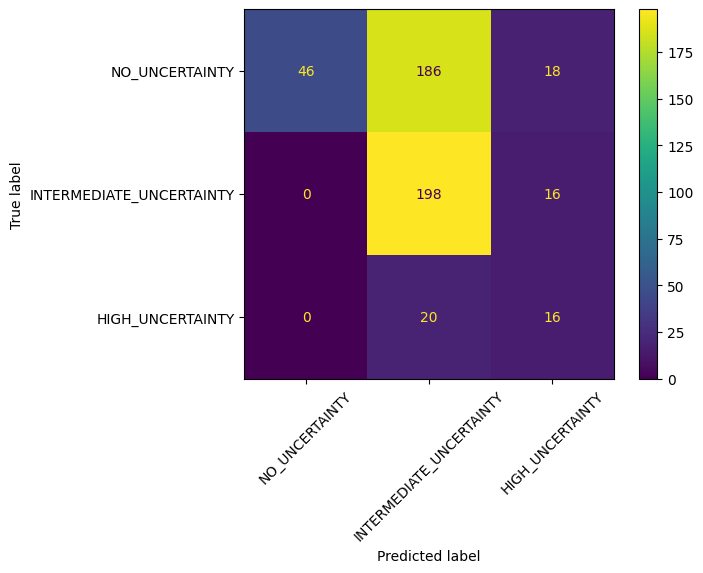

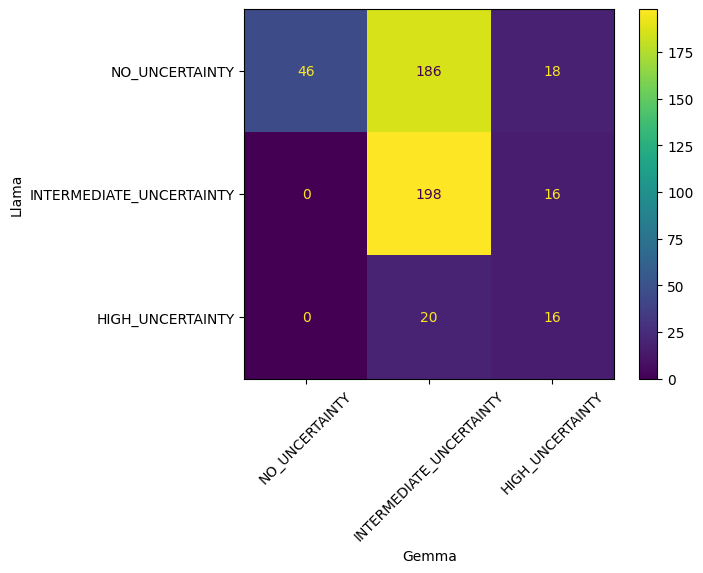

In [ ]:
qwen_labels[qwen_labels == None] = 'NO_UNCERTAINTY'
disp = ConfusionMatrixDisplay.from_predictions(
    qwen_labels, 
    gemma_labels, 
    labels=['NO_UNCERTAINTY', 'INTERMEDIATE_UNCERTAINTY', 'HIGH_UNCERTAINTY'], 
    xticks_rotation=45
)

fig, ax = plt.subplots()
disp.plot(ax=ax)

ax.set_xlabel('Gemma')
ax.set_ylabel('Qwen')
plt.xticks(rotation=45)

In [ ]:
qwen_labels[qwen_labels == None] = 'NO_UNCERTAINTY'
disp = ConfusionMatrixDisplay.from_predictions(
    qwen_labels, 
    llama_labels, 
    labels=['NO_UNCERTAINTY', 'INTERMEDIATE_UNCERTAINTY', 'HIGH_UNCERTAINTY'], 
    xticks_rotation=45
)

fig, ax = plt.subplots()
disp.plot(ax=ax)

ax.set_xlabel('Llama')
ax.set_ylabel('Qwen')
plt.xticks(rotation=45)